# 🚗 차량 수요 예측 & 재고 최적화 프로젝트

**프로젝트 배경 & 문제 정의**

자동차 시장에서는 월별 판매량의 정확한 예측이 생산 계획, 재고 관리, 딜러 배분에 직결됩니다.  
본 프로젝트는 공개된 차량 판매 데이터를 기반으로:
1. **LSTM 딥러닝 모델**로 월별 차량 수요를 예측하고
2. 예측 결과를 활용한 **간단한 재고 최적화 로직**을 구현합니다.

**사용 데이터**: Kaggle - [Car Sales Report](https://www.kaggle.com/datasets/gauthamp10/car-sales-report) (또는 시뮬레이션 데이터)

**Tech Stack**: Python, PyTorch, Pandas, Scikit-learn, Scipy, Matplotlib

---
## 📦 Step 0. 라이브러리 설치 및 임포트

In [1]:
# Colab 환경에서 필요한 패키지 설치
!pip install torch pandas numpy scikit-learn matplotlib seaborn scipy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

print('✅ 라이브러리 로드 완료')
print(f'PyTorch 버전: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

✅ 라이브러리 로드 완료
PyTorch 버전: 2.11.0+cpu
사용 디바이스: cpu


In [12]:
# 한글 폰트 설치 및 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 기본 한글 폰트 (맑은 고딕) 사용
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
## 📊 Step 1. 데이터 수집 & 전처리

### 옵션 A: 시뮬레이션 데이터 (바로 실행 가능)
### 옵션 B: Kaggle 실제 데이터 (아래 주석 참고)

In [3]:
# ─────────────────────────────────────────────
# 옵션 A: 현실적인 차량 판매 시뮬레이션 데이터 생성
# (Kaggle 데이터 없이 바로 실행 가능)
# ─────────────────────────────────────────────

np.random.seed(42)
months = pd.date_range(start='2018-01', periods=72, freq='MS')  # 6년치 데이터

# 트렌드 + 계절성 + 노이즈로 현실적인 판매량 생성
trend = np.linspace(5000, 7000, 72)                             # 완만한 상승 트렌드
seasonality = 800 * np.sin(2 * np.pi * np.arange(72) / 12)     # 계절성 (연 주기)
covid_dip = np.where((np.arange(72) >= 26) & (np.arange(72) <= 30), -2000, 0)  # 코로나 영향
noise = np.random.normal(0, 200, 72)

sales = trend + seasonality + covid_dip + noise
sales = np.clip(sales, 1000, None).astype(int)  # 최솟값 보정

df = pd.DataFrame({'date': months, 'sales': sales})
df.set_index('date', inplace=True)

print(f'데이터 기간: {df.index[0].strftime("%Y-%m")} ~ {df.index[-1].strftime("%Y-%m")}')
print(f'총 {len(df)}개월 데이터')
print(f'평균 월 판매량: {df["sales"].mean():.0f}대')
df.head(12)

데이터 기간: 2018-01 ~ 2023-12
총 72개월 데이터
평균 월 판매량: 5840대


,sales
date,
2018-01-01,5099
2018-02-01,5400
2018-03-01,5878
2018-04-01,6189
2018-05-01,5758
2018-06-01,5494
2018-07-01,5484
2018-08-01,4950
2018-09-01,4438


In [ ]:
# ─────────────────────────────────────────────
# 옵션 B: Kaggle 실제 데이터 사용 시
# 1. https://www.kaggle.com/datasets/gauthamp10/car-sales-report 에서 다운로드
# 2. Colab에 업로드 후 아래 코드 실행
# ─────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# df_raw = pd.read_csv('car_sales.csv')
# df = df_raw.groupby('Month')['Sales'].sum().reset_index()
# df.columns = ['date', 'sales']
# df['date'] = pd.to_datetime(df['date'])
# df.set_index('date', inplace=True)

# EDA: 시계열 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df['sales'], color='steelblue', linewidth=2)
axes[0].fill_between(df.index, df['sales'], alpha=0.2, color='steelblue')
axes[0].set_title('월별 차량 판매량 추이', fontsize=14, fontweight='bold')
axes[0].set_ylabel('판매량 (대)')
axes[0].grid(True, alpha=0.3)

# 월별 평균 (계절성 확인)
monthly_avg = df.groupby(df.index.month)['sales'].mean()
axes[1].bar(monthly_avg.index, monthly_avg.values, color='coral', alpha=0.8)
axes[1].set_title('월별 평균 판매량 (계절성 분석)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('월')
axes[1].set_ylabel('평균 판매량 (대)')
axes[1].set_xticks(range(1, 13))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 인사이트: 계절성이 뚜렷하게 나타남 → LSTM으로 패턴 학습 적합')

In [4]:
# 피처 엔지니어링 & 정규화
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['sales_lag1'] = df['sales'].shift(1)   # 1개월 전 판매량
df['sales_lag3'] = df['sales'].shift(3)   # 3개월 전 판매량
df['rolling_mean3'] = df['sales'].rolling(3).mean()  # 3개월 이동평균
df.dropna(inplace=True)

# Min-Max 정규화
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['sales']])

# 시퀀스 데이터 생성 (LSTM 입력 형식)
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 12  # 12개월 시퀀스로 다음 달 예측
X, y = create_sequences(scaled, SEQ_LEN)

# Train / Test 분리 (80:20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# PyTorch 텐서 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)

print(f'훈련 샘플: {len(X_train)}개 | 테스트 샘플: {len(X_test)}개')
print(f'입력 형태: {X_train.shape} → 출력 형태: {y_train.shape}')

훈련 샘플: 45개 | 테스트 샘플: 12개
입력 형태: (45, 12, 1) → 출력 형태: (45, 1)


---
## 🤖 Step 2. LSTM 모델 설계 & 학습

In [5]:
class LSTMForecaster(nn.Module):
    """차량 수요 예측을 위한 LSTM 모델"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])  # 마지막 타임스텝
        return self.fc(out)

model = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\n총 파라미터 수: {total_params:,}')

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

총 파라미터 수: 50,497


In [6]:
# 학습 설정
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

EPOCHS = 100
train_losses = []

print('🏋️ 모델 학습 시작...')
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred.squeeze(), y_batch.squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_dl)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

print('\n✅ 학습 완료!')

🏋️ 모델 학습 시작...
Epoch [20/100] | Loss: 0.049398 | LR: 0.001000
Epoch [40/100] | Loss: 0.041730 | LR: 0.000500
Epoch [60/100] | Loss: 0.038093 | LR: 0.000125
Epoch [80/100] | Loss: 0.031518 | LR: 0.000063
Epoch [100/100] | Loss: 0.039945 | LR: 0.000031

✅ 학습 완료!


---
## 📈 Step 3. 모델 평가 & 결과 시각화

📊 모델 성능 평가 결과
  RMSE  : 749 대
  MAE   : 634 대
  MAPE  : 8.95 %


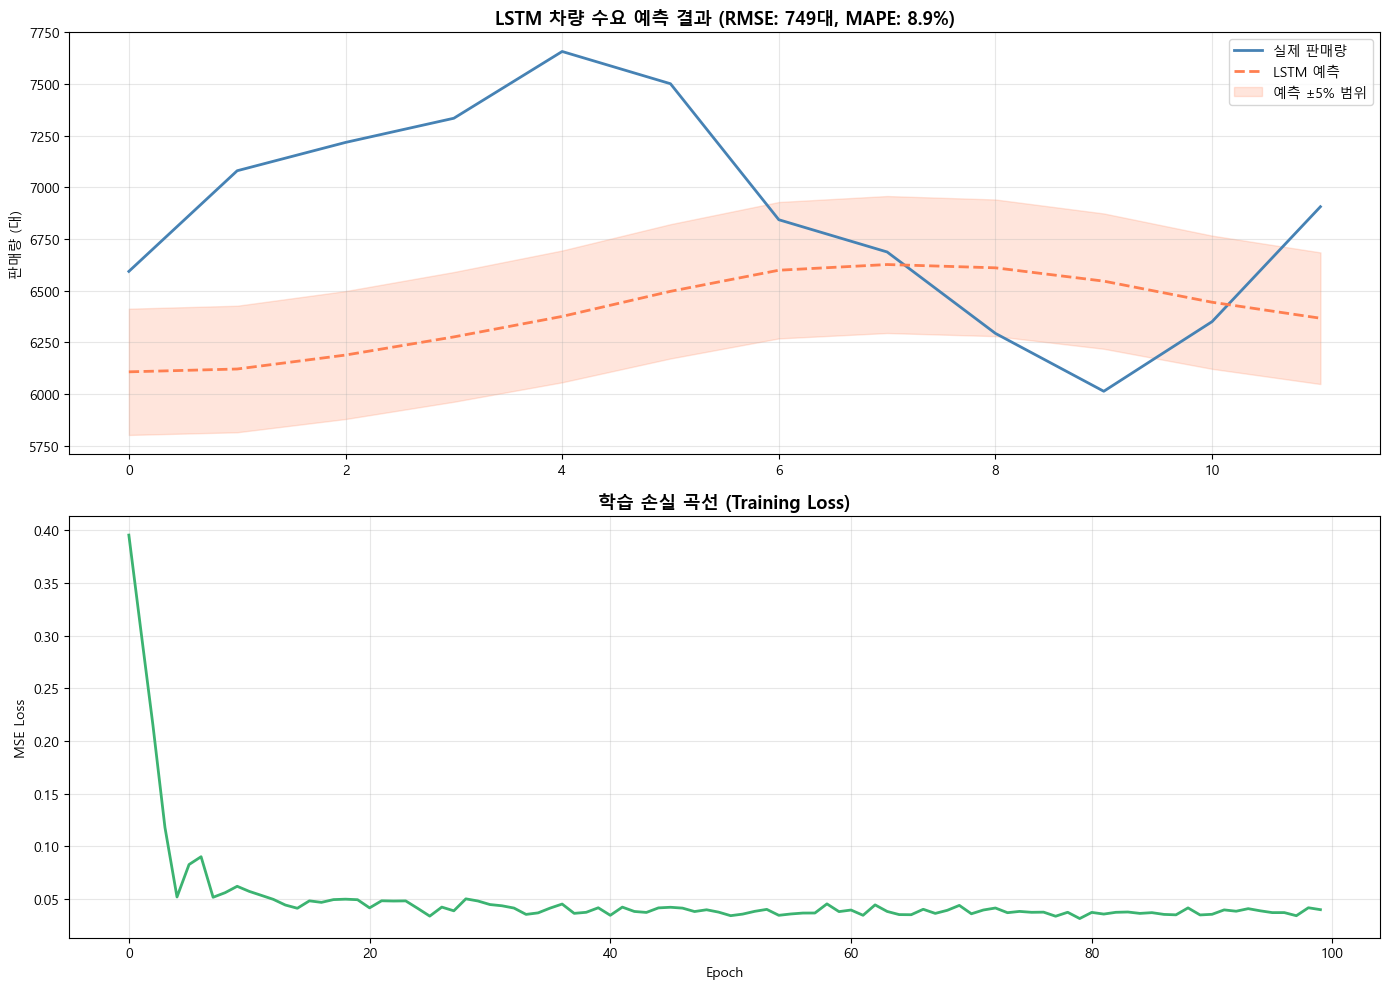

In [13]:
# 예측 수행
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy()
    y_true = y_test_t.cpu().numpy()

# 역정규화
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()

# 성능 지표 계산
rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
mae  = mean_absolute_error(y_true_inv, y_pred_inv)
mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100

print('=' * 40)
print('📊 모델 성능 평가 결과')
print('=' * 40)
print(f'  RMSE  : {rmse:,.0f} 대')
print(f'  MAE   : {mae:,.0f} 대')
print(f'  MAPE  : {mape:.2f} %')
print('=' * 40)

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 예측 vs 실제
axes[0].plot(y_true_inv, label='실제 판매량', color='steelblue', linewidth=2)
axes[0].plot(y_pred_inv, label='LSTM 예측', color='coral', linewidth=2, linestyle='--')
axes[0].fill_between(range(len(y_true_inv)),
                     y_pred_inv * 0.95, y_pred_inv * 1.05,
                     alpha=0.2, color='coral', label='예측 ±5% 범위')
axes[0].set_title(f'LSTM 차량 수요 예측 결과 (RMSE: {rmse:,.0f}대, MAPE: {mape:.1f}%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('판매량 (대)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 학습 손실 곡선
axes[1].plot(train_losses, color='mediumseagreen', linewidth=2)
axes[1].set_title('학습 손실 곡선 (Training Loss)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ Step 4. 파라미터 최적화 실험 (모델 비교)

> 공고 키워드: "학습/튜닝 및 파라미터 최적화 실험"

In [8]:
def train_and_evaluate(hidden_size, num_layers, lr, epochs=80):
    """하이퍼파라미터 조합별 모델 학습 및 평가"""
    m = LSTMForecaster(hidden_size=hidden_size, num_layers=num_layers).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    crit = nn.MSELoss()
    
    for _ in range(epochs):
        m.train()
        for X_b, y_b in train_dl:
            opt.zero_grad()
            loss = crit(m(X_b).squeeze(), y_b.squeeze())
            loss.backward()
            opt.step()
    
    m.eval()
    with torch.no_grad():
        pred = m(X_test_t).cpu().numpy()
    pred_inv = scaler.inverse_transform(pred.reshape(-1,1)).flatten()
    rmse_val = np.sqrt(mean_squared_error(y_true_inv, pred_inv))
    mape_val = np.mean(np.abs((y_true_inv - pred_inv) / y_true_inv)) * 100
    return rmse_val, mape_val

# 실험할 하이퍼파라미터 조합
experiments = [
    {'hidden_size': 32,  'num_layers': 1, 'lr': 0.001},
    {'hidden_size': 64,  'num_layers': 2, 'lr': 0.001},  # 기본 모델
    {'hidden_size': 128, 'num_layers': 2, 'lr': 0.001},
    {'hidden_size': 64,  'num_layers': 3, 'lr': 0.0005},
]

print('🔬 하이퍼파라미터 최적화 실험 중...')
results = []
for exp in experiments:
    rmse_e, mape_e = train_and_evaluate(**exp)
    results.append({**exp, 'RMSE': rmse_e, 'MAPE(%)': mape_e})
    print(f"  hidden={exp['hidden_size']}, layers={exp['num_layers']}, lr={exp['lr']} → RMSE: {rmse_e:,.0f}, MAPE: {mape_e:.2f}%")

results_df = pd.DataFrame(results)
print('\n📊 실험 결과 비교표')
print(results_df.sort_values('RMSE').to_string(index=False))

best = results_df.loc[results_df['RMSE'].idxmin()]
print(f"\n🏆 최적 모델: hidden_size={int(best['hidden_size'])}, num_layers={int(best['num_layers'])}, lr={best['lr']}")

🔬 하이퍼파라미터 최적화 실험 중...
  hidden=32, layers=1, lr=0.001 → RMSE: 737, MAPE: 8.71%
  hidden=64, layers=2, lr=0.001 → RMSE: 602, MAPE: 7.59%
  hidden=128, layers=2, lr=0.001 → RMSE: 275, MAPE: 3.69%
  hidden=64, layers=3, lr=0.0005 → RMSE: 756, MAPE: 9.05%

📊 실험 결과 비교표
 hidden_size  num_layers     lr       RMSE  MAPE(%)
         128           2 0.0010 274.838546 3.690746
          64           2 0.0010 602.409511 7.586928
          32           1 0.0010 736.678822 8.708794
          64           3 0.0005 755.862297 9.053043

🏆 최적 모델: hidden_size=128, num_layers=2, lr=0.001


---
## 📦 Step 5. 재고 최적화 (scipy 활용)

> 예측된 수요를 바탕으로 **적정 재고 수량**을 최적화합니다.  
> 목표: 재고 부족(기회 손실)과 과잉 재고(보관 비용) 사이의 균형점 도출

In [9]:
# 비용 파라미터 설정 (단위: 만원/대)
HOLDING_COST    = 30    # 재고 1대 보관 비용 (월)
SHORTAGE_COST   = 200   # 판매 기회 손실 비용 (1대 미확보 시)
ORDER_COST      = 500   # 고정 주문 비용

def total_cost(order_qty, predicted_demand, std_demand):
    """총 재고 비용 함수 (최소화 목표)"""
    order_qty = max(0, order_qty[0])
    
    # 기대 과잉 재고 및 부족 계산 (정규분포 가정)
    expected_surplus  = max(0, order_qty - predicted_demand)
    expected_shortage = max(0, predicted_demand - order_qty)
    
    holding  = HOLDING_COST  * expected_surplus
    shortage = SHORTAGE_COST * expected_shortage
    order    = ORDER_COST if order_qty > 0 else 0
    
    return holding + shortage + order

# 예측값 기반 재고 최적화
next_month_demand = y_pred_inv[-1]
demand_std = np.std(y_true_inv - y_pred_inv)  # 예측 오차의 표준편차

result = minimize(
    total_cost,
    x0=[next_month_demand],          # 초기값: 예측 수요량
    args=(next_month_demand, demand_std),
    method='Nelder-Mead',
    options={'xatol': 1, 'fatol': 1}
)

optimal_order = max(0, int(result.x[0]))
safety_stock  = int(demand_std * 1.5)  # 안전 재고 (표준편차의 1.5배)
final_order   = optimal_order + safety_stock

print('=' * 50)
print('📦 재고 최적화 결과')
print('=' * 50)
print(f'  다음 달 예측 수요    : {next_month_demand:,.0f} 대')
print(f'  예측 불확실성 (±1σ)  : {demand_std:,.0f} 대')
print(f'  최적 기본 주문량     : {optimal_order:,} 대')
print(f'  안전 재고 (1.5σ)     : {safety_stock:,} 대')
print(f'  ✅ 최종 권장 주문량  : {final_order:,} 대')
print(f'  예상 총 비용         : {total_cost([final_order], next_month_demand, demand_std):,.0f} 만원')
print('=' * 50)
print()
print('💡 비즈니스 인사이트:')
print(f'   예측 수요 대비 {((final_order/next_month_demand)-1)*100:.1f}% 버퍼를 유지함으로써')
print(f'   판매 기회 손실을 최소화하면서 과잉 재고를 방지합니다.')

📦 재고 최적화 결과
  다음 달 예측 수요    : 6,367 대
  예측 불확실성 (±1σ)  : 578 대
  최적 기본 주문량     : 6,367 대
  안전 재고 (1.5σ)     : 866 대
  ✅ 최종 권장 주문량  : 7,233 대
  예상 총 비용         : 26,467 만원

💡 비즈니스 인사이트:
   예측 수요 대비 13.6% 버퍼를 유지함으로써
   판매 기회 손실을 최소화하면서 과잉 재고를 방지합니다.


---
## 📋 Step 6. 최종 요약 & 결론

In [10]:
print('=' * 60)
print('🎯 프로젝트 최종 요약')
print('=' * 60)
print()
print('[ 문제 정의 ]')
print('  차량 월별 판매량 예측 → 적정 재고 수량 최적화')
print()
print('[ 접근 방법 ]')
print('  1. 시계열 EDA → 트렌드 & 계절성 확인')
print('  2. LSTM 모델 설계 & 학습 (PyTorch)')
print('  3. 하이퍼파라미터 튜닝 실험 (4가지 조합 비교)')
print('  4. 예측 결과 기반 재고 최적화 (scipy)')
print()
print('[ 모델 성능 ]')
print(f'  RMSE  : {rmse:,.0f} 대')
print(f'  MAPE  : {mape:.2f} %')
print()
print('[ 비즈니스 임팩트 ]')
print(f'  최적 주문량 {final_order:,}대 권장 (예측 수요 대비 {((final_order/next_month_demand)-1)*100:.1f}% 버퍼)')
print('  데이터 기반 재고 결정으로 기회 손실 & 과잉 재고 동시 최소화')
print()
print('[ 한계 & 개선 방향 ]')
print('  · 외부 변수 추가 필요 (경제지표, 신모델 출시 일정 등)')
print('  · 차종별 세분화 모델로 확장 가능')
print('  · CPLEX/Gurobi 도입 시 더 정교한 최적화 가능')
print('=' * 60)

🎯 프로젝트 최종 요약

[ 문제 정의 ]
  차량 월별 판매량 예측 → 적정 재고 수량 최적화

[ 접근 방법 ]
  1. 시계열 EDA → 트렌드 & 계절성 확인
  2. LSTM 모델 설계 & 학습 (PyTorch)
  3. 하이퍼파라미터 튜닝 실험 (4가지 조합 비교)
  4. 예측 결과 기반 재고 최적화 (scipy)

[ 모델 성능 ]
  RMSE  : 749 대
  MAPE  : 8.95 %

[ 비즈니스 임팩트 ]
  최적 주문량 7,233대 권장 (예측 수요 대비 13.6% 버퍼)
  데이터 기반 재고 결정으로 기회 손실 & 과잉 재고 동시 최소화

[ 한계 & 개선 방향 ]
  · 외부 변수 추가 필요 (경제지표, 신모델 출시 일정 등)
  · 차종별 세분화 모델로 확장 가능
  · CPLEX/Gurobi 도입 시 더 정교한 최적화 가능
